In [1]:
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Data import CodonTable
import os
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def read_gene_expression(file_path):
    """
    Read gene expression data with RNA-Seq RSEM normalized values

    Parameters:
    file_path (str): Path to gene expression file

    Returns:
    pandas.DataFrame: DataFrame with patient_id, sample_id and gene expression values
    """
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Gene expression data loaded: {df.shape[0]} samples, {df.shape[1]-2} genes")
    return df

def read_somatic_mutations(file_path):
    """
    Read somatic mutations data in MAF format

    Parameters:
    file_path (str): Path to mutation annotation file
    2`x
    Returns:
    pandas.DataFrame: DataFrame with mutation information
    """
    # Read the tab-separated MAF file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Somatic mutations data loaded: {df.shape[0]} mutations")
    return df

def read_patient_metadata(file_path):
    """
    Read patient clinical and pathological metadata

    Parameters:
    file_path (str): Path to patient metadata file

    Returns:
    pandas.DataFrame: DataFrame with patient clinical information
    """
    # Read the tab-separated metadata file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Patient metadata loaded: {df.shape[0]} patients")
    return df

def explore_data(gene_expr, somatic_mut, patient_meta):
    """
    Basic exploration of the three datasets
    """
    # Explore patient metadata
    print("\nPatient demographics:")
    print(f"Gender distribution:\n{patient_meta['gender'].value_counts()}")
    print(f"Age statistics:\n{patient_meta['age_at_initial_pathologic_diagnosis'].describe()}")

    # Analyze survival data
    print("\nSurvival statistics:")
    print(f"Overall survival events: {patient_meta['DSS'].sum()} deaths out of {patient_meta['DSS'].count()} patients")

    # Look at mutations per patient
    if 'patient_id' in somatic_mut.columns:
        mutations_per_patient = somatic_mut['patient_id'].value_counts()
        print(f"\nMutations per patient statistics:")
        print(mutations_per_patient.describe())

    # For gene expression, we could look at the most variable genes
    if gene_expr is not None and gene_expr.shape[1] > 2:
        print("\nGene expression statistics:")
        gene_columns = gene_expr.columns[2:]  # Skipping patient_id and sample_id
        gene_variance = gene_expr[gene_columns].var().sort_values(ascending=False)
        print(f"Top 5 most variable genes:\n{gene_variance.head(5)}")

gene_expression_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.expression.txt')
somatic_mutations_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.mutations.txt')
metadata_path = os.path.join(os.getcwd(),'Team_4_STAD', 'TCGA.STAD.metadata.txt')

gene_expr = read_gene_expression(gene_expression_path)
somatic_mut = read_somatic_mutations(somatic_mutations_path)
patient_meta = read_patient_metadata(metadata_path)

# explore_data(gene_expr, somatic_mut, patient_meta)


patient_meta['DSS']      = pd.to_numeric(patient_meta['DSS'], errors='coerce')
patient_meta['DSS.time'] = pd.to_numeric(patient_meta['DSS.time'], errors='coerce')

# 2. drop NaN
patient_meta = patient_meta.dropna(subset=['DSS', 'DSS.time'])

# 3. check categorical NaN
print("Before categorical clean:\n", patient_meta[['gender','ajcc_pathologic_tumor_stage','histological_grade']].isnull().sum())

patient_meta = patient_meta.dropna(subset=['gender','ajcc_pathologic_tumor_stage','histological_grade'])

print("After categorical clean:\n", patient_meta[['gender','ajcc_pathologic_tumor_stage','histological_grade']].isnull().sum())

mutant_ids = somatic_mut.loc[somatic_mut['Hugo_Symbol']=='TP53','patient_id'].unique()
patient_meta['mutation_status'] = np.where(
    patient_meta['patient_id'].isin(mutant_ids),
    'mutant','wildtype'
)

patient_meta = patient_meta.reset_index(drop=True)

Gene expression data loaded: 447 samples, 20531 genes
Somatic mutations data loaded: 234941 mutations
Patient metadata loaded: 415 patients
Before categorical clean:
 gender                         0
ajcc_pathologic_tumor_stage    0
histological_grade             0
dtype: int64
After categorical clean:
 gender                         0
ajcc_pathologic_tumor_stage    0
histological_grade             0
dtype: int64


In [2]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:
    """
    Handle missing data by dropping or filling NaN values.

    Parameters:
    df (pd.DataFrame): The DataFrame to process.
    subset_cols (list): If provided, only consider these cols when dropping NaNs.
    method (str): "drop" to drop NaNs, "fill" to fill numeric cols with their mean.

    Returns:
    pd.DataFrame: Cleaned DataFrame.
    """
    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:
    """
    Fit and plot a Kaplan–Meier curve on DSS.time / DSS.
    """
    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:
    """
    Fit a Cox Proportional Hazards model.
    """
    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    cph.print_summary()
    return cph

def logrank_test_between_groups(df: pd.DataFrame,
                                group_col: str,
                                group1,
                                group2,
                                time_col: str = 'DSS.time',
                                event_col: str = 'DSS'):
    """
    Perform log-rank test comparing two subgroups.
    """
    def clean(sub: pd.DataFrame):
        tmp = sub[[time_col, event_col]].copy()
        tmp[time_col] = pd.to_numeric(tmp[time_col], errors='coerce')
        tmp[event_col] = pd.to_numeric(tmp[event_col], errors='coerce')
        return handle_missing_data(tmp, subset_cols=[time_col, event_col], method="drop")
    g1 = clean(df[df[group_col] == group1])
    g2 = clean(df[df[group_col] == group2])
    if g1.empty or g2.empty:
        raise ValueError("One group is empty after cleaning")
    res = logrank_test(
        g1[time_col],
        g2[time_col],
        event_observed_A=g1[event_col],
        event_observed_B=g2[event_col]
    )
    print(res.summary)
    return res

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:
    """
    Add `mutation_status` = 'mutant' if Hugo_Symbol == mutation_gene else 'wildtype'.
    """
    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    """
    Compute Tumor Mutation Burden (TMB) as the count of mutations per patient.
    Returns a Series indexed by patient_id.
    """
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

In [3]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    """
    Compute Tumor Mutation Burden (TMB) as the count of mutations per patient.
    Returns a Series indexed by patient_id.
    """
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

# —— 在主流程中加入 TMB 计算和合并 —— #

# 1) 初步标记 TP53 突变
somatic_mut = add_mutation_status_column(somatic_mut, 'Hugo_Symbol', 'TP53')

# 2) 计算 TMB
tmb_series = compute_tmb(somatic_mut)

# 3) 合并到 patient_meta
patient_meta = patient_meta.copy()
patient_meta = patient_meta.merge(tmb_series, how='left',
                                  left_on='patient_id', right_index=True)
# TMB 未在 somatic_mut 中出现的病人设为 0
patient_meta['TMB'] = patient_meta['TMB'].fillna(0)


# 4) 根据中位数将 TMB 分组
median_tmb = patient_meta['TMB'].median()
patient_meta['TMB_group'] = np.where(patient_meta['TMB'] >= median_tmb,
                                     'high_TMB', 'low_TMB')

# 5) 重新清理生存分析列（以 DSS 为例，也可改成 OS）
patient_meta['DSS']      = pd.to_numeric(patient_meta['DSS'], errors='coerce')
patient_meta['DSS.time'] = pd.to_numeric(patient_meta['DSS.time'], errors='coerce')
patient_meta = patient_meta.dropna(subset=['DSS','DSS.time'])
patient_meta = patient_meta.dropna(subset=['gender','ajcc_pathologic_tumor_stage','histological_grade'])

# KM by TMB group

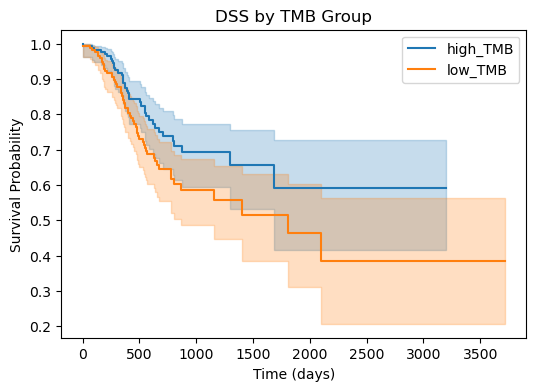

/opt/anaconda3/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column ajcc_pathologic_tumor_stage_Stage IA have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['DSS'].astype(bool)
>>> print(df.loc[events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())
>>> print(df.loc[~events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())

A very low variance means that the column ajcc_pathologic_tumor_stage_Stage IA completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.909

<lifelines.CoxPHFitter: fitted with 383 total observations, 288 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 383
number of events observed = 95
   partial log-likelihood = -472.46
         time fit was run = 2025-05-28 02:17:00 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
age_at_initial_pathologic_diagnosis          0.02      1.02      0.01            0.00            0.04                1.00                1.04
logTMB                                      -0.22      0.80      0.08           -0.38           -0.06                0.68                0.95
gender_MALE                                  0.39      1.48      0.24           -0.07            0.86                0.93                2.36
ajcc_pathologic_tumor_stage_Stage IA        -0.29      0.75   9367.33       -18359.92        18359.34                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IB        15.91  8.13e+06   9088.95       -17798.10        17829.92                0.00                 inf
ajcc_pathologic_tumor_stage_Stage II        16.82  2.02e+07   9088.95       -17797.19        17830.83                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIA       16.73  1.84e+07   9088.95       -17797.28        17830.74                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIB       16.29  1.18e+07   9088.95       -17797.72        17830.30                0.00                 inf
ajcc_pathologic_tumor_stage_Stage III       18.33  9.16e+07   9088.95       -17795.68        17832.34                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIA      16.95  2.29e+07   9088.95       -17797.06        17830.96                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIB      16.79  1.96e+07   9088.95       -17797.22        17830.80                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIC      17.35  3.44e+07   9088.95       -17796.66        17831.36                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IV        17.81  5.43e+07   9088.95       -17796.20        17831.82                0.00                 inf
ajcc_pathologic_tumor_stage_[Discrepancy]   17.58  4.30e+07   9088.95       -17796.43        17831.59                0.00                 inf
ajcc_pathologic_tumor_stage_[Not Available] -0.15      0.86  35663.46       -69899.24        69898.94                0.00                 inf
histological_grade_G2                       -0.58      0.56      0.75           -2.05            0.89                0.13                2.45
histological_grade_G3                       -0.29      0.75      0.73           -1.73            1.14                0.18                3.13
histological_grade_GX                        0.05      1.05      1.01           -1.92            2.02                0.15                7.56
mutation_status_wildtype                    -0.13      0.87      0.22           -0.56            0.29                0.57                1.34

                                             cmp to     z    p  -log2(p)
covariate                                                               
age_at_initial_pathologic_diagnosis            0.00  2.00 0.05      4.45
logTMB                                         0.00 -2.63 0.01      6.86
gender_MALE                                    0.00  1.66 0.10      3.38
ajcc_pathologic_tumor_stage_Stage IA           0.00 -0.00 1.00      0.00
ajcc_pathologic_tumor_stage_Stage IB           0.00  0.00 1.00      0.00
ajcc_pathologic_tumor_stage_Stage II           0.00  0.00 1.00      0.00
ajcc_pathologic_tumor_stage_Stage IIA          0.00  0.00 1.00      0.00
aj

   test_statistic         p  -log2(p)
0        0.054415  0.815552  0.294152
   test_statistic         p  -log2(p)
0        4.143776  0.041788  4.580772


<Axes: >

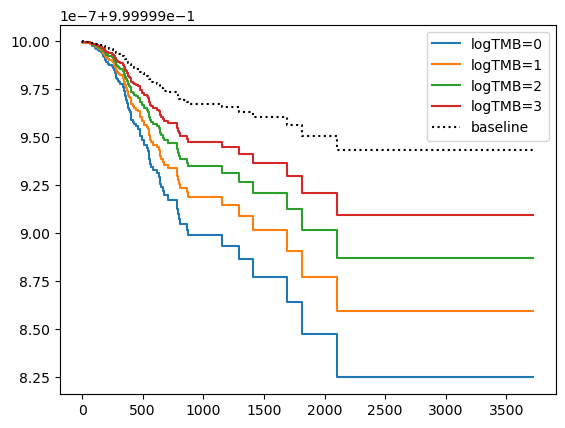

In [4]:
kmf = KaplanMeierFitter()
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
for grp, sub in patient_meta.groupby('TMB_group'):
    kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=grp)
    kmf.plot_survival_function(ci_show=True)
plt.title("DSS by TMB Group")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

numeric = ['age_at_initial_pathologic_diagnosis', 'TMB']
categorical = ['gender', 'ajcc_pathologic_tumor_stage', 'histological_grade', 'mutation_status']
patient_meta['logTMB'] = np.log1p(patient_meta['TMB'])

cph = cox_proportional_hazards(
    patient_meta,
    time_col   = 'DSS.time',
    event_col  = 'DSS',
    numeric_covs     = ['age_at_initial_pathologic_diagnosis','logTMB'],
    categorical_covs = ['gender','ajcc_pathologic_tumor_stage','histological_grade','mutation_status']
)
# cph = cox_proportional_hazards(patient_meta,
#                                time_col='DSS.time',
#                                event_col='DSS',
#                                numeric_covs=numeric,
#                                categorical_covs=categorical)

# C) Log-rank comparing mutant vs. wildtype
lr1 = logrank_test_between_groups(patient_meta,
                                  group_col='mutation_status',
                                  group1='mutant',
                                  group2='wildtype',
                                  time_col='DSS.time',
                                  event_col='DSS')

# D) Log-rank comparing high_TMB vs low_TMB
lr2 = logrank_test_between_groups(patient_meta,
                                  group_col='TMB_group',
                                  group1='high_TMB',
                                  group2='low_TMB',
                                  time_col='DSS.time',
                                  event_col='DSS')

# E) logTMB
cph.plot_partial_effects_on_outcome("logTMB",
    values=[0, 1, 2, 3], # log1p(TMB)=0,1,2,3
    plot_baseline=True)

# KM by most mutated genes

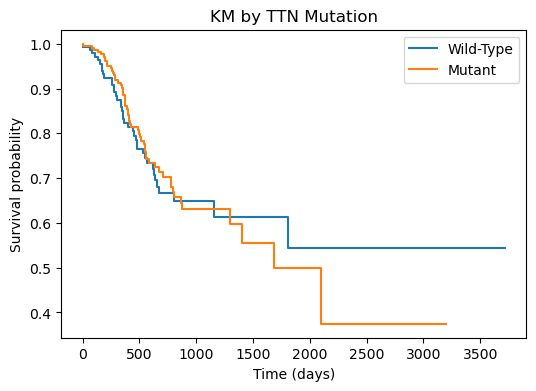

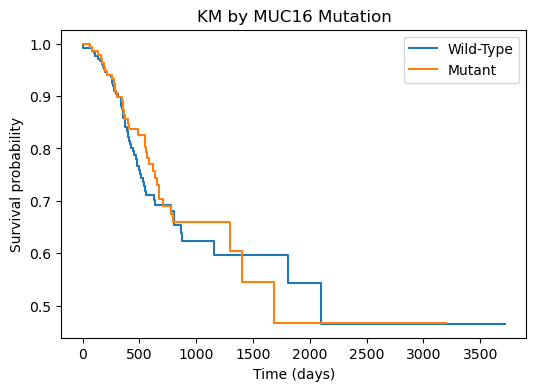

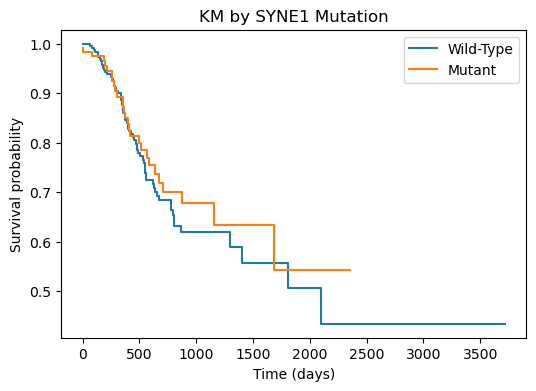

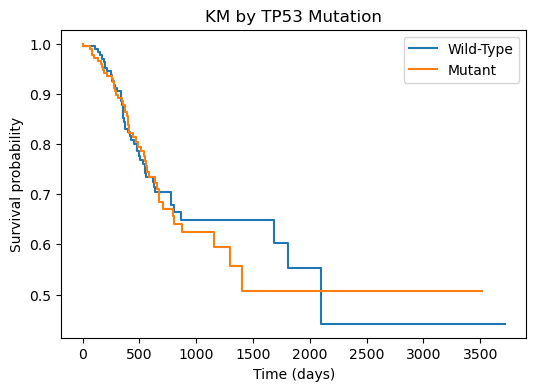

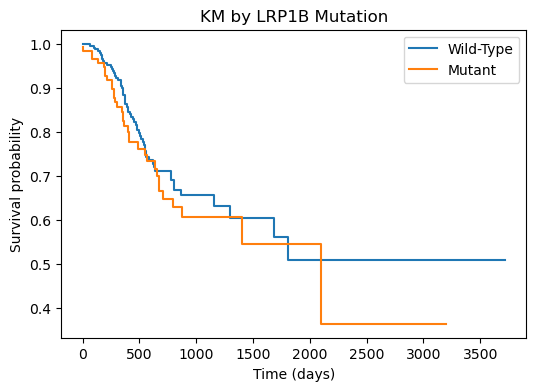

    gene  logrank_p     coxHR  HR_CI_lower  HR_CI_upper
0    TTN   0.897299  0.985778    -0.425846     0.397198
1  MUC16   0.629285  0.908645    -0.512757     0.321156
2  SYNE1   0.537717  0.956258    -0.493255     0.403801
3   TP53   0.815552  1.012459    -0.393326     0.418089
4  LRP1B   0.376506  1.191514    -0.253178     0.603628


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

top_genes = (
    somatic_mut['Hugo_Symbol']
    .value_counts()
    .nlargest(5)
    .index
    .tolist()
)

results = []

for gene in top_genes:
    patient_meta[f'{gene}_mut'] = np.where(
        patient_meta['patient_id'].isin(
            somatic_mut[somatic_mut['Hugo_Symbol']==gene]['patient_id']),
        1, 0
    )
    
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(6,4))
    for status, label in [(0, 'Wild-Type'), (1, 'Mutant')]:
        sub = patient_meta[patient_meta[f'{gene}_mut']==status]
        kmf.fit(sub['DSS.time'], sub['DSS'], label=label)
        kmf.plot_survival_function(ci_show=False)
    plt.title(f"KM by {gene} Mutation")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival probability")
    plt.show()

    lr = logrank_test(
        patient_meta.loc[patient_meta[f'{gene}_mut']==0, 'DSS.time'],
        patient_meta.loc[patient_meta[f'{gene}_mut']==1, 'DSS.time'],
        event_observed_A=patient_meta.loc[patient_meta[f'{gene}_mut']==0, 'DSS'],
        event_observed_B=patient_meta.loc[patient_meta[f'{gene}_mut']==1, 'DSS']
    )


    cph_df = patient_meta[['DSS.time','DSS','age_at_initial_pathologic_diagnosis','gender', f'{gene}_mut']].copy()
    cph_df = pd.get_dummies(cph_df, columns=['gender'], drop_first=True)
    cph_df = cph_df.dropna()
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col='DSS.time', event_col='DSS')
    hr = np.exp(cph.params_[f'{gene}_mut'])
    ci = cph.confidence_intervals_.loc[f'{gene}_mut'].values

    results.append({
        'gene': gene,
        'logrank_p': lr.p_value,
        'coxHR': hr,
        'HR_CI_lower': ci[0],
        'HR_CI_upper': ci[1]
    })

res_df = pd.DataFrame(results)
print(res_df)


# Log-rank Test FDR for Top 20 Mutated Genes

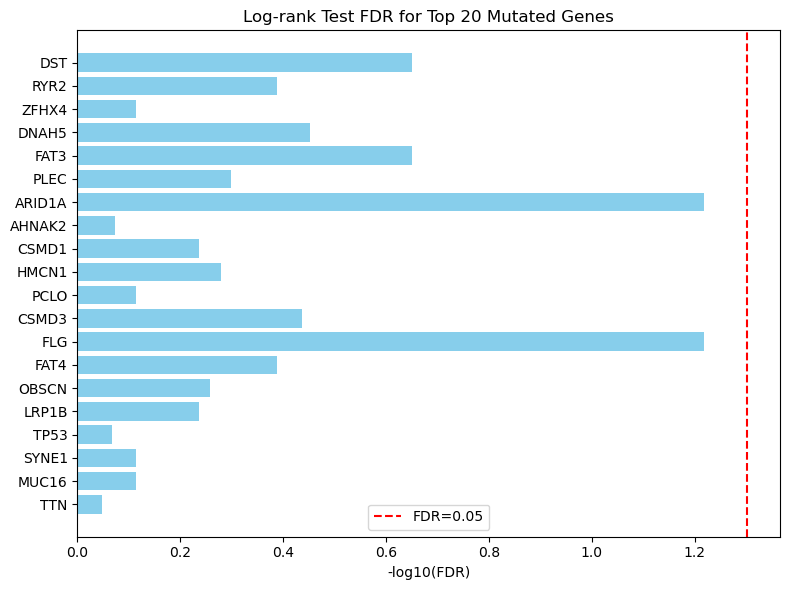

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests

top_genes = somatic_mut['Hugo_Symbol'].value_counts().nlargest(20).index.tolist()
results = []
for gene in top_genes:
    patient_meta[f'{gene}_mut'] = np.where(
        patient_meta['patient_id'].isin(
            somatic_mut[somatic_mut['Hugo_Symbol']==gene]['patient_id']
        ), 1, 0
    )
    if patient_meta[f'{gene}_mut'].nunique() < 2:
        continue
    wt = patient_meta[patient_meta[f'{gene}_mut']==0]
    mut = patient_meta[patient_meta[f'{gene}_mut']==1]
    lr = logrank_test(
        wt['DSS.time'], mut['DSS.time'],
        event_observed_A=wt['DSS'], event_observed_B=mut['DSS']
    )
    results.append({'gene': gene, 'logrank_p': lr.p_value})

res_df = pd.DataFrame(results)
res_df['fdr'] = multipletests(res_df['logrank_p'], method='fdr_bh')[1]
res_df['minus_log10_fdr'] = -np.log10(res_df['fdr'])

plt.figure(figsize=(8,6))
plt.barh(res_df['gene'], res_df['minus_log10_fdr'], color='skyblue')
plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='FDR=0.05')
plt.xlabel('-log10(FDR)')
plt.title('Log-rank Test FDR for Top 20 Mutated Genes')
plt.legend()
plt.tight_layout()
plt.show()


# KM by top 3 genes in logrank test

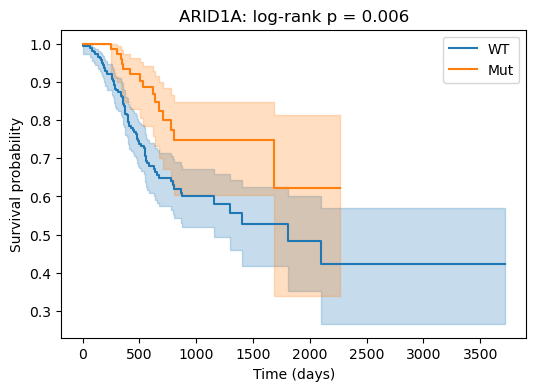

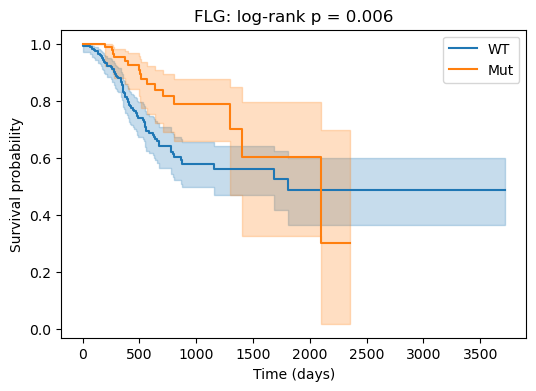

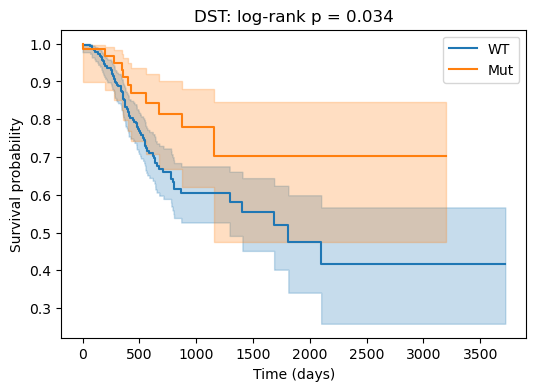

In [7]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


# sort by p value
top3 = res_df.sort_values('logrank_p', ascending=True)['gene'].head(3).tolist()

kmf = KaplanMeierFitter()

for gene in top3:
    plt.figure(figsize=(6,4))
    for status, label in [(0, 'WT'), (1, 'Mut')]:
        sub = patient_meta[patient_meta[f'{gene}_mut'] == status]
        kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=label)
        kmf.plot_survival_function(ci_show=True)
    pval = res_df.loc[res_df['gene'] == gene, 'logrank_p'].values[0]
    plt.title(f"{gene}: log-rank p = {pval:.3f}")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival probability")
    plt.show()


# KM by gender, ajcc stages, and hazard ratios etc.

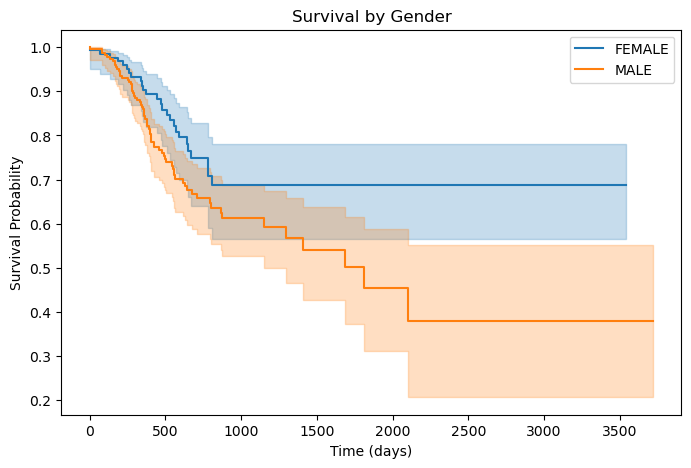

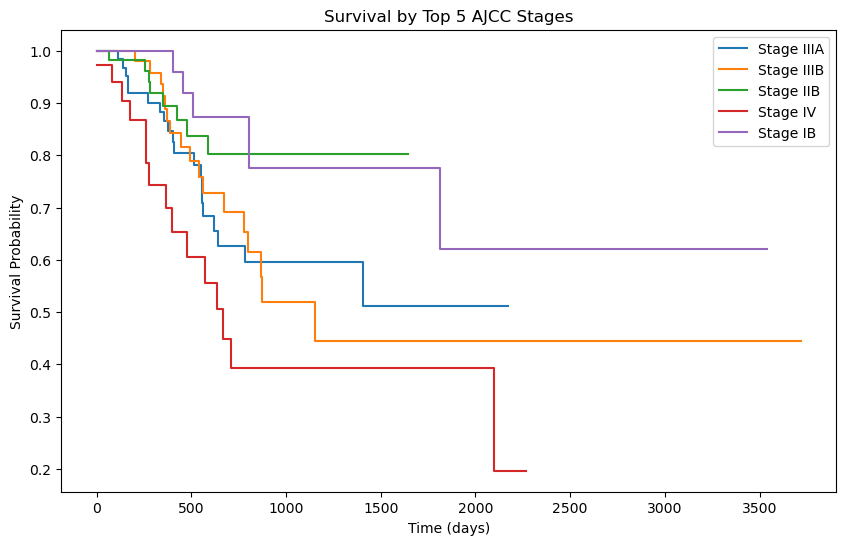

/opt/anaconda3/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column ajcc_pathologic_tumor_stage_Stage IA have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['DSS'].astype(bool)
>>> print(df.loc[events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())
>>> print(df.loc[~events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())

A very low variance means that the column ajcc_pathologic_tumor_stage_Stage IA completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.909

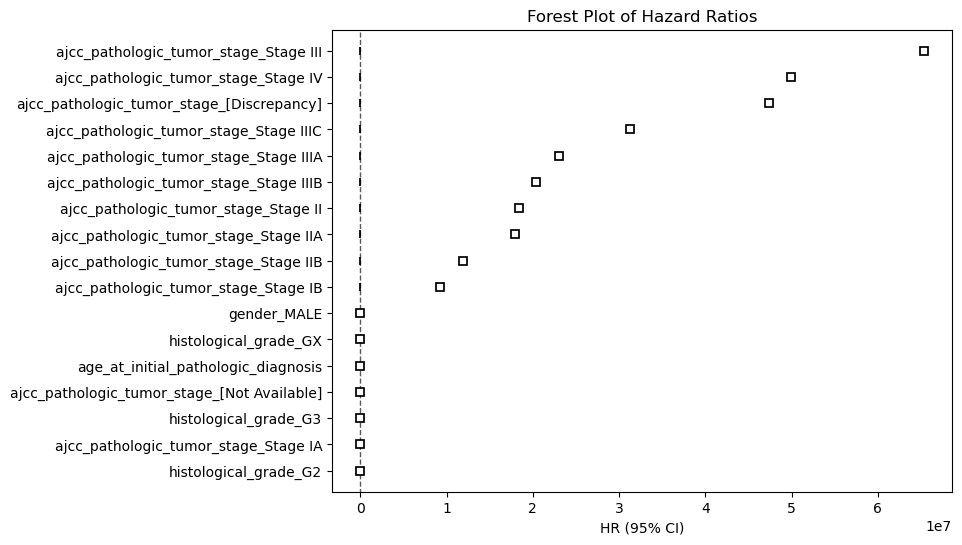

In [8]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

#—— 1) Kaplan–Meier by gender ——#
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,5))
for grp, sub in patient_meta.groupby('gender'):
    kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=grp)
    kmf.plot_survival_function(ci_show=True)
plt.title("Survival by Gender")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

#—— 2) Kaplan–Meier by AJCC stages ——#
plt.figure(figsize=(10,6))
top_stages = patient_meta['ajcc_pathologic_tumor_stage'].value_counts().index[:5]
for stage in top_stages:
    sub = patient_meta[patient_meta['ajcc_pathologic_tumor_stage']==stage]
    kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=stage)
    kmf.plot_survival_function(ci_show=False)
plt.title("Survival by Top 5 AJCC Stages")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

#—— 3) Forest Plot of Hazard Ratios ——#
numeric = ['age_at_initial_pathologic_diagnosis']
categorical = ['gender', 'ajcc_pathologic_tumor_stage', 'histological_grade']
df = patient_meta[['DSS.time','DSS'] + numeric + categorical].copy()
df['DSS.time'] = pd.to_numeric(df['DSS.time'], errors='coerce')
df['DSS']      = pd.to_numeric(df['DSS'], errors='coerce')
df = df.dropna(subset=['DSS.time','DSS'] + numeric)
df = pd.get_dummies(df, columns=categorical, drop_first=True)
cph = CoxPHFitter()
cph.fit(df, duration_col='DSS.time', event_col='DSS')

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Forest Plot of Hazard Ratios")
plt.show()
